# Mutual Fund Performance Analytics

This notebook analyzes the performance of mutual fund schemes using different financial metrics. The analysis includes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, and Benchmark Comparison.

In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 20)

## Load Cleaned Datasets

The cleaned datasets prepared during the data cleaning phase are loaded for performance analysis.

In [81]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [82]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

## Dataset Overview

The following section verifies the datasets before performing performance calculations.

In [83]:
print("Fund Master :", fund_master.shape)

print("NAV History :", nav.shape)

print("Scheme Performance :", performance.shape)

print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (64320, 3)
Scheme Performance : (40, 19)
Benchmark : (8050, 3)


In [84]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [85]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Daily Returns Analysis

Daily return measures the percentage change in the Net Asset Value (NAV) from one trading day to the next. It helps in understanding the day-to-day movement of each mutual fund scheme.

In [86]:
# Sort NAV data before calculating returns

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [87]:
# Calculate daily returns for each scheme

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [88]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-08,515.1639,0.000000
6,100016,2022-01-09,515.1639,0.000000
7,100016,2022-01-10,510.7136,-0.008639
8,100016,2022-01-11,513.5542,0.005562
9,100016,2022-01-12,512.3195,-0.002404


# Daily Return Distribution

The histogram below shows the distribution of daily returns across all mutual fund schemes. Most returns are expected to be concentrated around zero with a few positive and negative extremes.

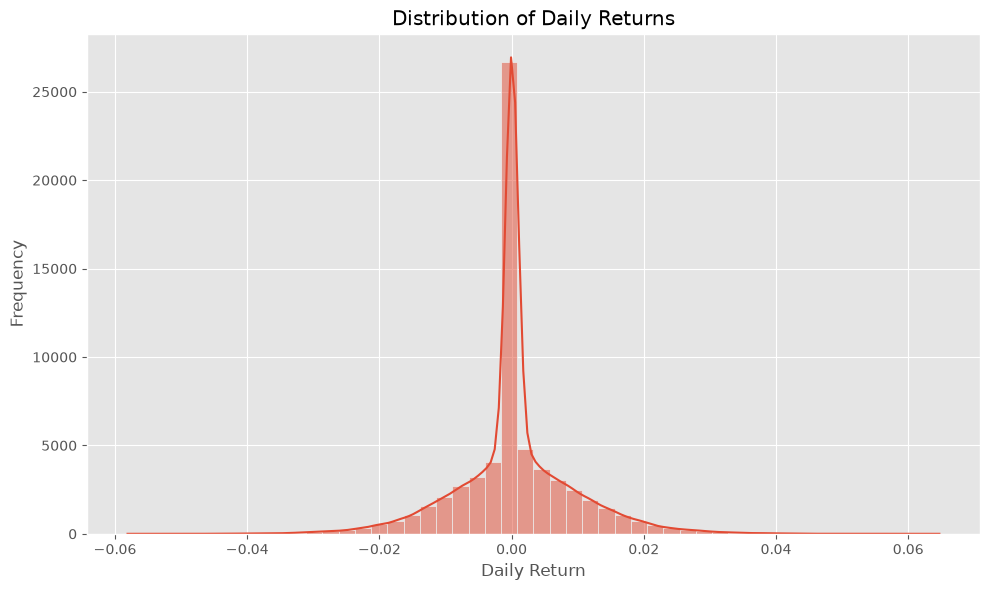

In [89]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Observation

The distribution of daily returns is centered close to zero, indicating that most daily NAV changes are relatively small. A few observations lie on both the positive and negative sides, representing larger market movements.

In [90]:
nav["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

### Summary

The calculated daily returns will be used in the following sections to compute performance metrics such as Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown.

## Compound Annual Growth Rate (CAGR)

Compound Annual Growth Rate (CAGR) measures the average annual growth of a mutual fund over a specific period. It provides a better understanding of long-term performance compared to simple returns.

In [91]:
# Create a separate dataframe for CAGR calculation

cagr_df = nav.copy()

cagr_df = cagr_df.sort_values(["amfi_code", "date"])

In [92]:
def calculate_cagr(group, years):

    group = group.sort_values("date").copy()

    end_date = group["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    filtered = group[group["date"] >= start_date]

    if len(filtered) < 2:
        return np.nan

    start_nav = filtered.iloc[0]["nav"]
    end_nav = filtered.iloc[-1]["nav"]

    elapsed_days = (filtered.iloc[-1]["date"] - filtered.iloc[0]["date"]).days

    if start_nav <= 0 or end_nav <= 0 or elapsed_days <= 0:
        return np.nan

    return (end_nav / start_nav) ** (365.25 / elapsed_days) - 1

In [93]:
cagr_result = pd.DataFrame()

cagr_result["amfi_code"] = sorted(nav["amfi_code"].unique())

In [94]:
cagr_result["cagr_1yr"] = (
    nav.groupby("amfi_code")
    .apply(lambda x: calculate_cagr(x, 1), include_groups=False)
    .values
)

cagr_result["cagr_3yr"] = (
    nav.groupby("amfi_code")
    .apply(lambda x: calculate_cagr(x, 3), include_groups=False)
    .values
)

cagr_result["cagr_5yr"] = (
    nav.groupby("amfi_code")
    .apply(lambda x: calculate_cagr(x, 5), include_groups=False)
    .values
)

In [95]:
cagr_result = cagr_result.merge(

    fund_master[["amfi_code", "scheme_name"]],

    on="amfi_code",

    how="left"
)

cagr_result

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
0,100016,-0.022258,0.012924,0.026371,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037076,0.039155,0.044582,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532772,0.324340,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479638,0.289602,0.235384,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.240003,-0.041515,0.079388,ABSL Small Cap Fund - Regular - Growth
...,...,...,...,...,...
35,148568,0.142798,0.147444,0.225169,Mirae Asset Emerging Bluechip Fund - Regular -...
36,148569,0.397838,0.291714,0.319495,Mirae Asset Tax Saver Fund - Regular - Growth
37,149322,0.181246,0.180397,0.133933,DSP Top 100 Equity Fund - Regular - Growth
38,149323,0.214974,0.268631,0.295811,DSP Midcap Fund - Regular - Growth


### CAGR Comparison

The table below compares the annualized growth rate of all mutual fund schemes over one-year, three-year, and five-year periods.

In [96]:
cagr_result = cagr_result[
    [
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

cagr_result.head(10)

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.012924,0.026371
1,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039155,0.044582
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232
3,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.289602,0.235384
4,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.041515,0.079388
5,ABSL Liquid Fund - Regular - Growth,0.072418,0.063143,0.065090
6,UTI Nifty 50 Index Fund - Regular - Growth,0.202229,0.196624,0.182324
7,UTI Mid Cap Fund - Regular - Growth,-0.168080,-0.007672,0.011717
8,UTI Flexi Cap Fund - Regular - Growth,0.135930,0.255497,0.168411
9,Nippon India Large Cap Fund - Regular - Growth,0.340079,0.226466,0.240495


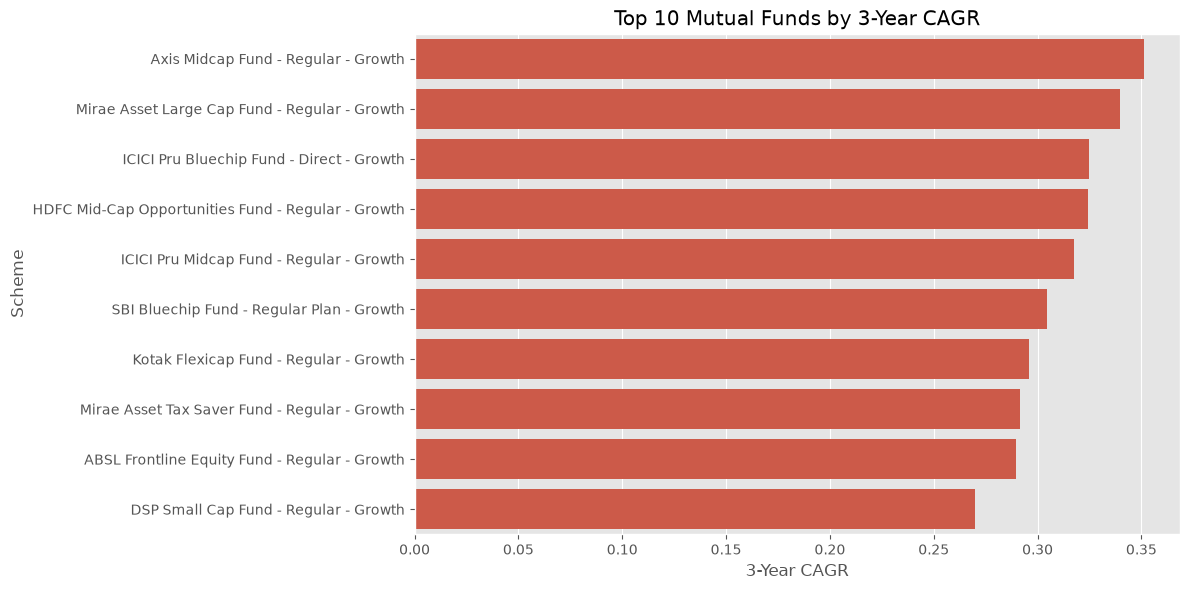

In [97]:
plt.figure(figsize=(12,6))

top10 = cagr_result.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

sns.barplot(
    data=top10,
    x="cagr_3yr",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by 3-Year CAGR")

plt.xlabel("3-Year CAGR")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Observation

Most schemes showed positive annualized growth over the three-year period. The comparison helps identify funds that consistently delivered better long-term returns.

In [98]:
cagr_result.describe()

,cagr_1yr,cagr_3yr,cagr_5yr
count,40.000000,40.000000,40.000000
mean,0.194445,0.164105,0.167357
std,0.229306,0.122036,0.103090
min,-0.428195,-0.117033,0.011717
25%,0.073832,0.065994,0.068618
50%,0.174871,0.182286,0.166073
75%,0.271826,0.268957,0.244883
max,0.828516,0.351025,0.328274


## Sharpe Ratio

The Sharpe Ratio measures the risk-adjusted return of a mutual fund. It compares the excess return over the risk-free rate with the total volatility of returns. A higher Sharpe Ratio indicates better performance relative to risk.

In [99]:
risk_free_rate = 0.065

trading_days = 252

sharpe_result = []

In [100]:
for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * trading_days

        annual_std = returns.std() * np.sqrt(trading_days)

        sharpe_ratio = (annual_return - risk_free_rate) / annual_std

    else:

        sharpe_ratio = np.nan

    sharpe_result.append([code, sharpe_ratio])

In [101]:
sharpe_df = pd.DataFrame(

    sharpe_result,

    columns=["amfi_code", "sharpe_ratio"]

)

sharpe_df = sharpe_df.merge(

    fund_master[["amfi_code", "scheme_name"]],

    on="amfi_code",

    how="left"

)

sharpe_df.head()

,amfi_code,sharpe_ratio,scheme_name
0,100016,-0.321019,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-1.039941,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.808268,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.717409,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.052618,ABSL Small Cap Fund - Regular - Growth


In [102]:
sharpe_df = sharpe_df.sort_values(

    "sharpe_ratio",

    ascending=False

)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.068224,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.965561,Kotak Flexicap Fund - Regular - Growth
36,148569,0.919047,Mirae Asset Tax Saver Fund - Regular - Growth
25,120505,0.883256,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.860977,SBI Bluechip Fund - Regular Plan - Growth
38,149323,0.832885,DSP Midcap Fund - Regular - Growth
2,100033,0.808268,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.758851,Nippon India Large Cap Fund - Regular - Growth
16,119094,0.730547,Axis Midcap Fund - Regular - Growth
3,101206,0.717409,ABSL Frontline Equity Fund - Regular - Growth


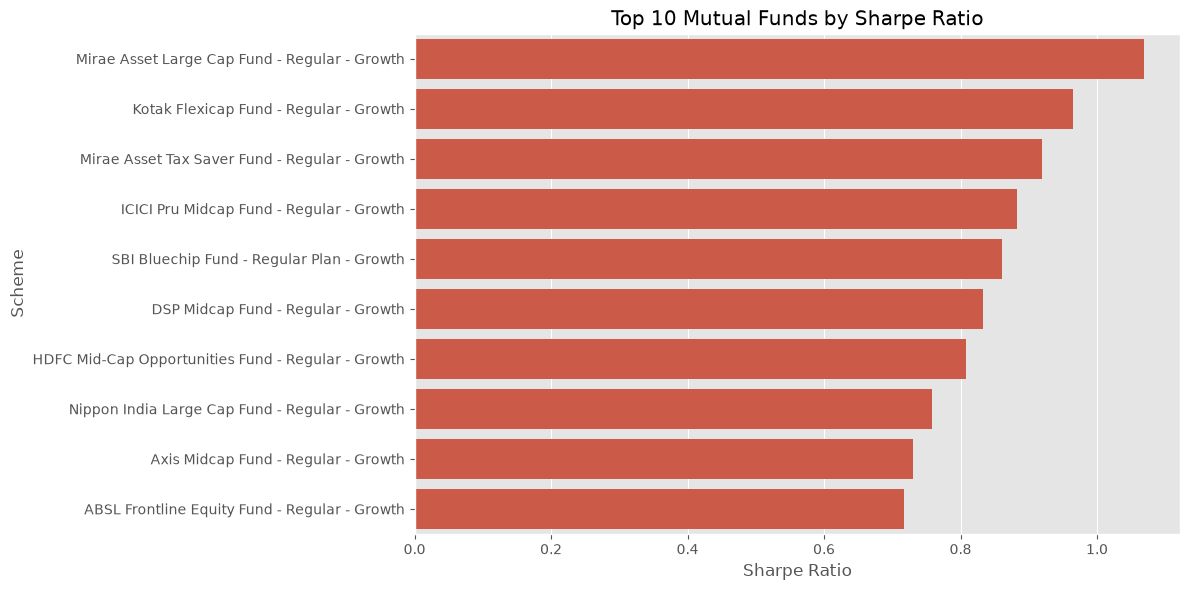

In [103]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=sharpe_df.head(10),

    x="sharpe_ratio",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Observation

Funds with higher Sharpe Ratios delivered better risk-adjusted returns during the analysis period. These funds generated relatively higher returns while maintaining lower overall volatility.

## Sortino Ratio

The Sortino Ratio measures the risk-adjusted return of a mutual fund by considering only downside risk. Unlike the Sharpe Ratio, it ignores positive return volatility and focuses on harmful fluctuations.

In [104]:
risk_free_rate = 0.065

sortino_result = []

trading_days = 252

In [105]:
for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    if len(downside_returns) > 1:

        annual_return = returns.mean() * trading_days

        downside_std = downside_returns.std() * np.sqrt(trading_days)

        sortino = (annual_return - risk_free_rate) / downside_std

    else:

        sortino = np.nan

    sortino_result.append([code, sortino])

In [106]:
sortino_df = pd.DataFrame(

    sortino_result,

    columns=["amfi_code", "sortino_ratio"]

)

sortino_df = sortino_df.merge(

    fund_master[["amfi_code", "scheme_name"]],

    on="amfi_code",

    how="left"
)

sortino_df.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.472822,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-1.461220,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.144216,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.063909,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.075668,ABSL Small Cap Fund - Regular - Growth


In [107]:
sortino_df = sortino_df.sort_values(

    "sortino_ratio",

    ascending=False

)

sortino_df.head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,1.490739,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.479503,Kotak Flexicap Fund - Regular - Growth
36,148569,1.352815,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.291483,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.285843,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.167793,DSP Midcap Fund - Regular - Growth
2,100033,1.144216,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.098880,Nippon India Large Cap Fund - Regular - Growth
21,119598,1.067256,SBI Small Cap Fund - Regular Plan - Growth
24,120504,1.063964,ICICI Pru Bluechip Fund - Direct - Growth


### Observation

The Sortino Ratio focuses on downside risk and highlights funds that generated better returns while experiencing fewer negative return fluctuations. Higher values indicate stronger downside risk-adjusted performance.

## Alpha and Beta Analysis

Alpha measures the excess return generated by a mutual fund compared to its benchmark, while Beta measures the sensitivity of the fund's returns to market movements. Linear regression is used to estimate both values using benchmark returns.

In [108]:
# Prepare benchmark daily returns

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

In [109]:
# Select NIFTY100 benchmark

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [110]:
alpha_beta = []

In [111]:
for code, group in nav.groupby("amfi_code"):

    merged = group.merge(
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna(subset=["daily_return", "benchmark_return"])

    if len(merged) > 20:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope

        alpha = intercept * 252

    else:

        beta = np.nan

        alpha = np.nan

    alpha_beta.append([code, alpha, beta])

In [112]:
alpha_beta_df = pd.DataFrame(

    alpha_beta,

    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df = alpha_beta_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"
)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [113]:
alpha_beta_df = alpha_beta_df.sort_values(

    "alpha",

    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth


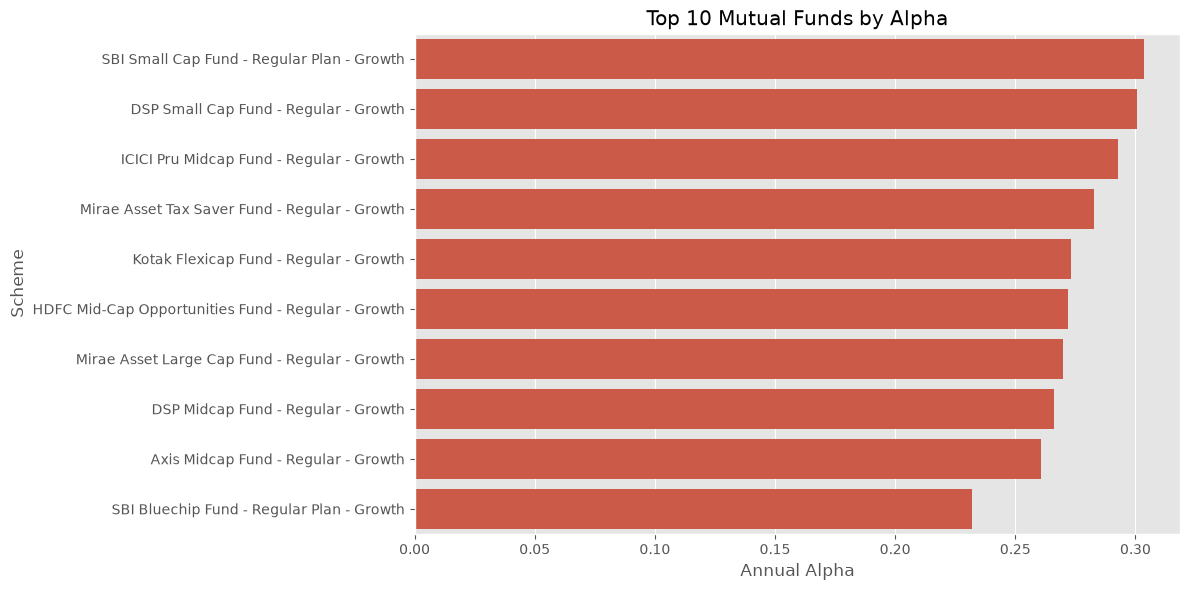

In [114]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=alpha_beta_df.head(10),

    x="alpha",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds by Alpha")

plt.xlabel("Annual Alpha")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Observation

Funds with higher Alpha generated returns above what would normally be expected based on market performance. Beta indicates how closely each fund follows movements in the benchmark index.

In [115]:
alpha_beta_df.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


## Maximum Drawdown

Maximum Drawdown measures the largest decline in a mutual fund's NAV from its previous peak. It is an important risk metric because it shows how much an investor could have lost during the worst-performing period.

In [116]:
drawdown_result = []

In [117]:
for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    worst_row = group.loc[group["drawdown"].idxmin()]

    drawdown_result.append([
        code,
        worst_row["drawdown"],
        worst_row["date"]
    ])

In [118]:
drawdown_df = pd.DataFrame(

    drawdown_result,

    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_date"
    ]
)

drawdown_df = drawdown_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"
)

drawdown_df.head()

,amfi_code,max_drawdown,worst_date,scheme_name
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [119]:
drawdown_df = drawdown_df.sort_values(

    "max_drawdown"
)

drawdown_df.head(10)

,amfi_code,max_drawdown,worst_date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth


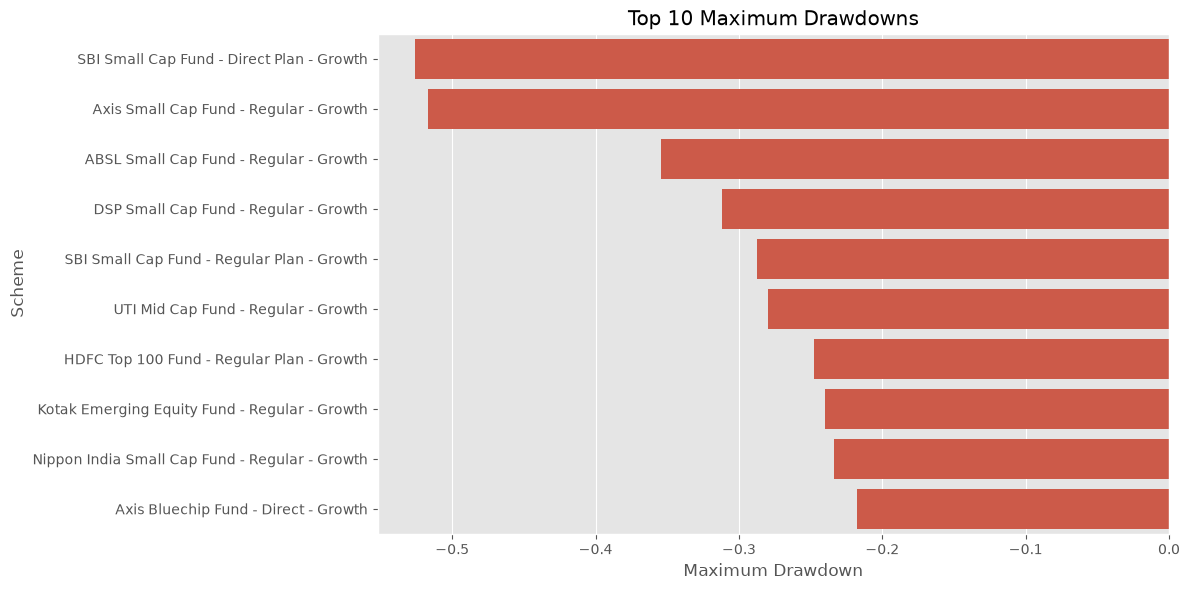

In [120]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=drawdown_df.head(10),

    x="max_drawdown",

    y="scheme_name"

)

plt.title("Top 10 Maximum Drawdowns")

plt.xlabel("Maximum Drawdown")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Observation

Maximum Drawdown highlights the worst decline experienced by each mutual fund from its previous peak. Funds with smaller drawdowns generally indicate better downside protection during market corrections.

In [121]:
drawdown_df.describe()

,amfi_code,max_drawdown,worst_date
count,40.000000,40.000000,40
mean,120247.000000,-0.178729,2024-03-12 18:00:00
min,100016.000000,-0.525742,2022-02-04 00:00:00
25%,118632.750000,-0.215927,2023-05-28 00:00:00
50%,119551.500000,-0.163070,2024-02-07 00:00:00
75%,120842.250000,-0.117653,2025-02-08 18:00:00
max,149324.000000,-0.000977,2026-05-11 00:00:00
std,14534.998667,0.112686,NaN


## Fund Scorecard

The Fund Scorecard combines multiple performance measures into a single score. It considers long-term returns, risk-adjusted performance, Alpha, expense ratio, and maximum drawdown to rank mutual fund schemes.

In [122]:
scorecard = cagr_result.copy()

In [123]:
scorecard = scorecard.merge(

    sharpe_df[["scheme_name", "sharpe_ratio"]],

    on="scheme_name"

)

scorecard = scorecard.merge(

    alpha_beta_df[["scheme_name", "alpha"]],

    on="scheme_name"

)

scorecard = scorecard.merge(

    drawdown_df[["scheme_name", "max_drawdown"]],

    on="scheme_name"

)

scorecard = scorecard.merge(

    performance[["scheme_name", "expense_ratio_pct"]],

    on="scheme_name"

)

In [124]:
scorecard.head()

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.012924,0.026371,-0.321019,0.037476,-0.247344,1.55
1,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039155,0.044582,-1.039941,0.042818,-0.043083,0.56
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232,0.808268,0.271954,-0.162172,1.38
3,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.289602,0.235384,0.717409,0.213998,-0.112916,1.60
4,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.041515,0.079388,0.052618,0.108971,-0.354469,1.53


In [125]:
scorecard["return_rank"] = scorecard["cagr_3yr"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [126]:
scorecard["fund_score"] = (

    0.30 * scorecard["return_rank"]

    + 0.25 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["alpha_rank"]

    + 0.15 * scorecard["expense_rank"]

    + 0.10 * scorecard["drawdown_rank"]

)

In [127]:
scorecard["fund_score"] = (

    100

    * (scorecard["fund_score"].max() - scorecard["fund_score"])

    / (scorecard["fund_score"].max() - scorecard["fund_score"].min())

)

In [128]:
scorecard = scorecard.sort_values(

    "fund_score",

    ascending=False

)

scorecard.head(10)

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,0.203760,0.339920,0.309741,1.068224,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,100.000000
25,ICICI Pru Midcap Fund - Regular - Growth,0.296277,0.317692,0.328274,0.883256,0.292636,-0.181885,1.36,5.0,4.0,3.0,15.0,25.0,95.263158
30,Kotak Flexicap Fund - Regular - Growth,0.266776,0.295751,0.309075,0.965561,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,94.035088
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232,0.808268,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,92.280702
24,ICICI Pru Bluechip Fund - Direct - Growth,0.130738,0.324789,0.232951,0.714682,0.211948,-0.125883,0.80,3.0,11.0,13.0,12.0,12.0,90.350877
16,Axis Midcap Fund - Regular - Growth,0.222779,0.351025,0.282144,0.730547,0.260767,-0.209609,1.38,1.0,9.0,9.0,17.0,28.0,88.771930
19,SBI Bluechip Fund - Regular Plan - Growth,0.604893,0.304486,0.258047,0.860977,0.232010,-0.150124,1.54,6.0,5.0,10.0,30.5,17.0,83.070175
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.397838,0.291714,0.319495,0.919047,0.282704,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,82.368421
21,SBI Small Cap Fund - Regular Plan - Growth,0.828516,0.266631,0.324235,0.711690,0.303370,-0.287060,1.43,12.0,13.0,1.0,21.0,36.0,74.385965
3,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.289602,0.235384,0.717409,0.213998,-0.112916,1.60,9.0,10.0,12.0,36.5,9.0,73.771930


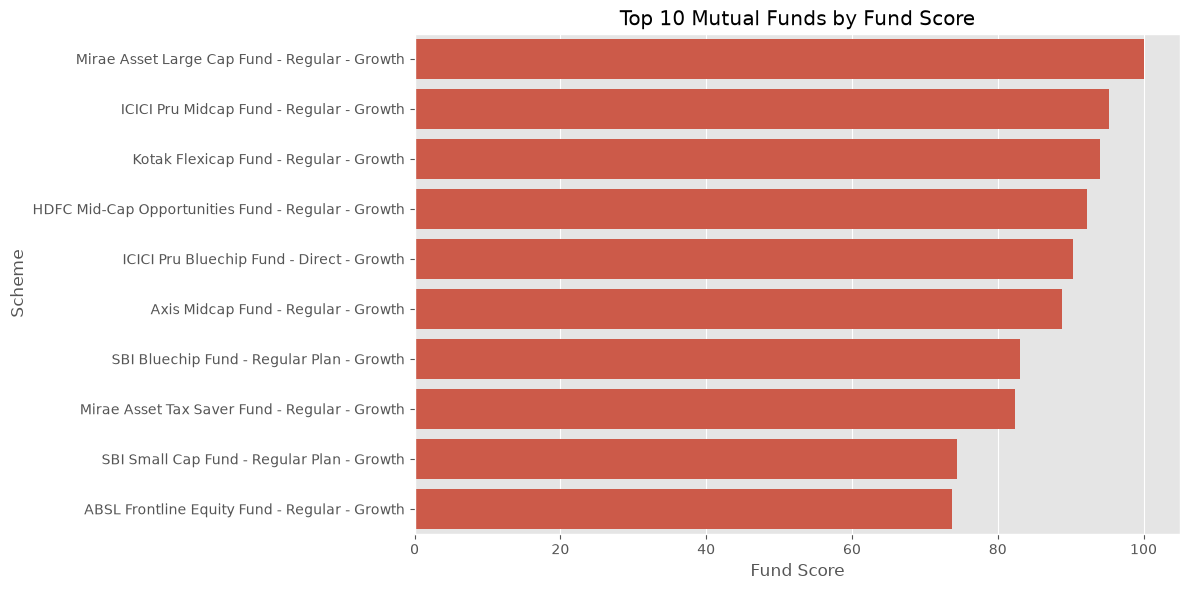

In [129]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=scorecard.head(10),

    x="fund_score",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds by Fund Score")

plt.xlabel("Fund Score")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Observation

The Fund Score combines multiple performance indicators into a single value. Funds with higher scores demonstrated stronger long-term returns, better risk-adjusted performance, lower expenses, and smaller drawdowns.

In [130]:
scorecard.to_csv(

    "../reports/fund_scorecard.csv",

    index=False

)

## Benchmark Comparison

This section compares the performance of the top five mutual fund schemes with the NIFTY50 and NIFTY100 benchmark indices over the last three years. It also computes the tracking error of each fund against the NIFTY100 benchmark.

In [131]:
# Add AMFI code to scorecard

scorecard = scorecard.drop(
    columns=["amfi_code", "amfi_code_x", "amfi_code_y"],
    errors="ignore"
)

scorecard = scorecard.merge(
    fund_master[["scheme_name", "amfi_code"]],
    on="scheme_name",
    how="left"
)

scorecard.head()


,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,amfi_code
0,Mirae Asset Large Cap Fund - Regular - Growth,0.203760,0.339920,0.309741,1.068224,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,100.000000,148567
1,ICICI Pru Midcap Fund - Regular - Growth,0.296277,0.317692,0.328274,0.883256,0.292636,-0.181885,1.36,5.0,4.0,3.0,15.0,25.0,95.263158,120505
2,Kotak Flexicap Fund - Regular - Growth,0.266776,0.295751,0.309075,0.965561,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,94.035088,120843
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232,0.808268,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,92.280702,100033
4,ICICI Pru Bluechip Fund - Direct - Growth,0.130738,0.324789,0.232951,0.714682,0.211948,-0.125883,0.80,3.0,11.0,13.0,12.0,12.0,90.350877,120504


In [132]:
# Select top five funds

top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,amfi_code
0,Mirae Asset Large Cap Fund - Regular - Growth,0.203760,0.339920,0.309741,1.068224,0.269838,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,100.000000,148567
1,ICICI Pru Midcap Fund - Regular - Growth,0.296277,0.317692,0.328274,0.883256,0.292636,-0.181885,1.36,5.0,4.0,3.0,15.0,25.0,95.263158,120505
2,Kotak Flexicap Fund - Regular - Growth,0.266776,0.295751,0.309075,0.965561,0.273305,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,94.035088,120843
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324340,0.301232,0.808268,0.271954,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,92.280702,100033
4,ICICI Pru Bluechip Fund - Direct - Growth,0.130738,0.324789,0.232951,0.714682,0.211948,-0.125883,0.80,3.0,11.0,13.0,12.0,12.0,90.350877,120504


In [133]:
# Prepare top five fund NAV data

top5_codes = top5["amfi_code"].tolist()

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top5_nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100033,2022-01-03,107.3758,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [134]:
# Filter only the last three years

start_date = "2023-01-01"

top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

benchmark_plot = benchmark[
    (benchmark["date"] >= start_date) &
    (benchmark["index_name"].isin(["NIFTY50", "NIFTY100"]))
]

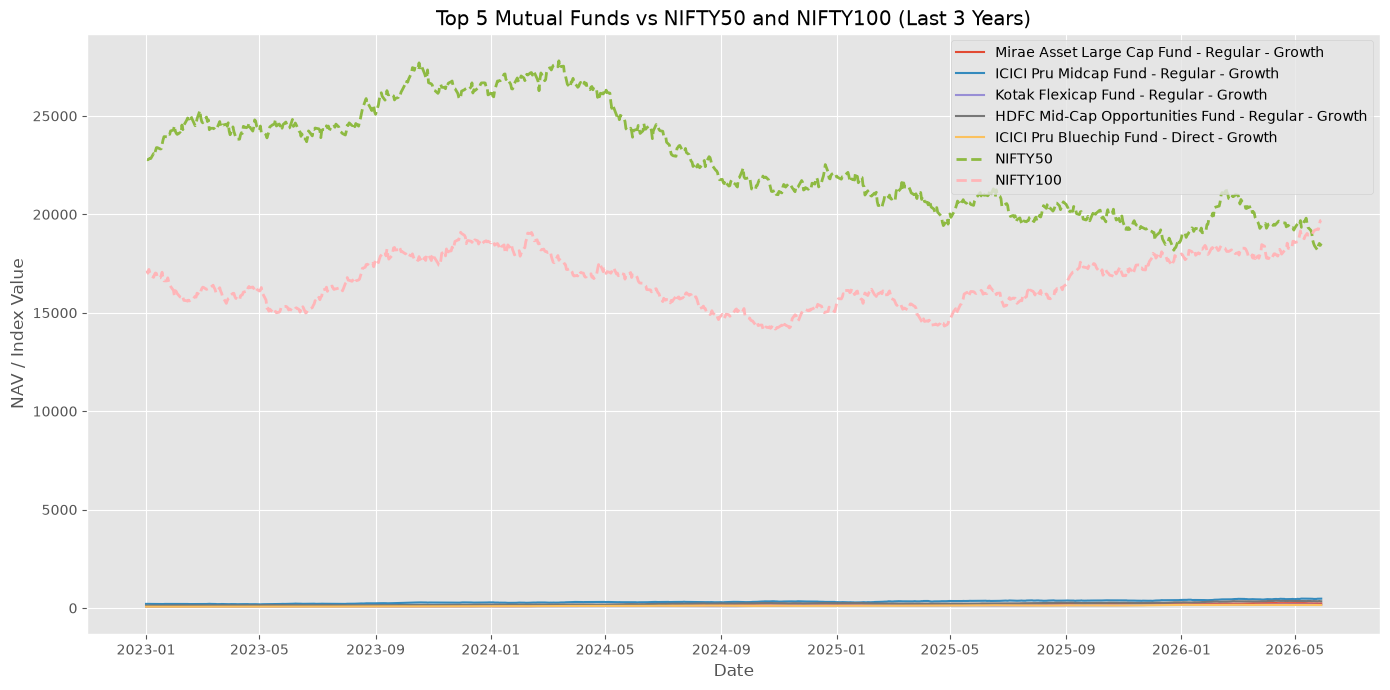

In [135]:
plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=temp["scheme_name"].iloc[0]
    )

for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linestyle="--",
        linewidth=2,
        label=index
    )

plt.title("Top 5 Mutual Funds vs NIFTY50 and NIFTY100 (Last 3 Years)")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig("../charts/benchmark_comparison.png", dpi=300)

plt.show()

In [136]:
# Prepare NIFTY100 benchmark returns

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

In [137]:
tracking_error = []

for code in top5_codes:

    fund = top5_nav[
        top5_nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = fund.merge(
        nifty100,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    error = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append([
        code,
        error
    ])

In [138]:
tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df = tracking_error_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

tracking_error_df

,amfi_code,tracking_error,scheme_name
0,148567,0.187393,Mirae Asset Large Cap Fund - Regular - Growth
1,120505,0.232415,ICICI Pru Midcap Fund - Regular - Growth
2,120843,0.206844,Kotak Flexicap Fund - Regular - Growth
3,100033,0.226553,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,0.188775,ICICI Pru Bluechip Fund - Direct - Growth


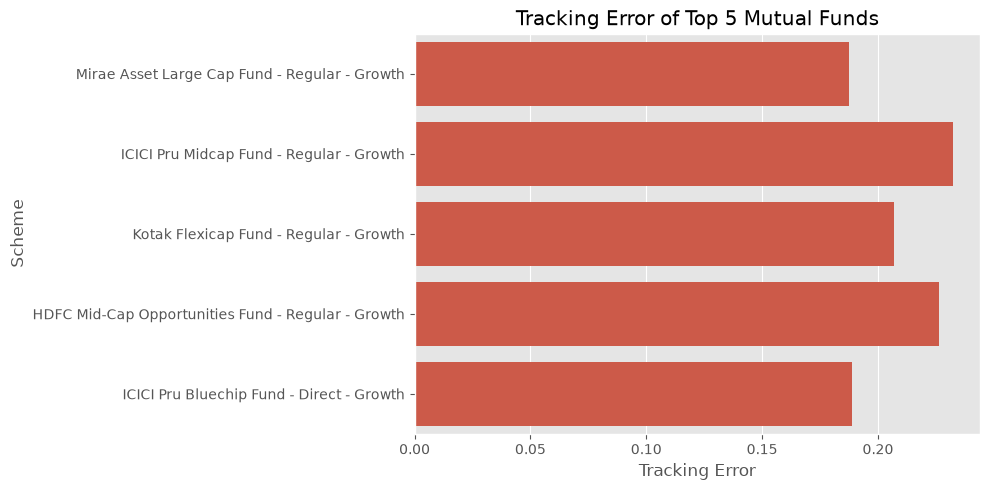

In [139]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=tracking_error_df,
    x="tracking_error",
    y="scheme_name"
)

plt.title("Tracking Error of Top 5 Mutual Funds")

plt.xlabel("Tracking Error")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

In [140]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

### Observation

The benchmark comparison indicates that the selected top-performing mutual funds generally followed the movement of the benchmark indices over the last three years. Funds with lower tracking error exhibited returns that were closer to the benchmark, while higher tracking error reflected greater deviation from benchmark performance.